https://kawaihome.link/jbooks/comp-phys/integral/scattering_angle.html
Scattering Angle
$$\theta = \pi-2\phi$$
$$\phi_0 = \int_{r_{min}}^\infty \frac{\rho dr}{r^2\sqrt{1-(\rho^2/r^2)-(2U/mv_\infty^2)}}$$
Introduce $u = \frac{1}{r}$
$$\phi = \int_0^{u_0} \frac{\rho}{\sqrt{1-\rho^2u^2-\frac{U(1/u)}{E}}}du$$
$$\phi_Y = \int_0^{u_0} \frac{\rho}{\sqrt{1-\rho^2u^2-\frac{uA\exp(-k_0/u)}{E}}}du$$

Remove singularity at closest approach by subtracting coulomb scattering
$$\phi_C = \int_0^{u_0}\frac{b}{\sqrt{1-b^2u^2-\frac{Cu}{E}}}du = \frac{\pi}{2}-\tan^{-1}(\frac{C}{2\rho E})$$
Matching singularities
$$1-\rho^2u_0^2-\frac{u_0A\exp(-k_0/u_0)}{E} = 1-\rho^2u_0^2-\frac{Cu_0}{E}$$
$$C = A\exp(-k_0/u_0)$$
$$\Delta \phi = \phi_Y-\phi_C = \rho\int_0^{u_0} \frac{1}{\sqrt{1-\rho^2u^2 - \frac{uA\exp(-k_0/u)}{E}}}-\frac{1}{\sqrt{1-\rho^2u^2 - \frac{Cu}{E}}} du$$
$$\phi_Y = \Delta \phi + \phi_C$$
https://journals.aps.org/prl/pdf/10.1103/PhysRevLett.90.225002
use reduced mass


C:\Users\shaoq\AppData\Local\Temp\ipykernel_15568\3032308016.py:68: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  result[i]=minimize(umaxfunc,guess,args=(rho[i],A,k0,E)).x
C:\Users\shaoq\AppData\Local\Temp\ipykernel_15568\3032308016.py:68: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  result[i]=minimize(umaxfunc,guess,args=(rho[i],A,k0,E)).x
C:\Users\shaoq\AppData\Local\Temp\ipykernel_15568\3032308016.py:68: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  result[i]=m

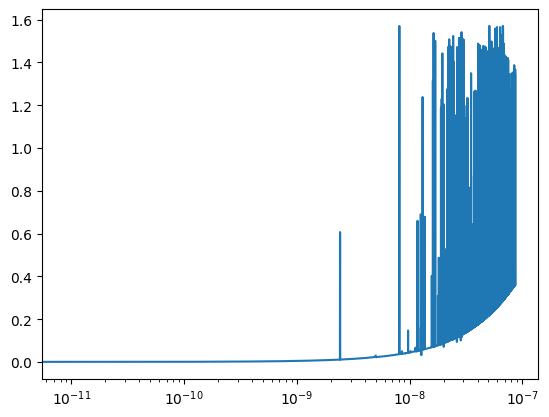

In [ ]:
import numpy as np
import scipy as scp
import numpy as np
import math as math
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.integrate import quad
from scipy.optimize import newton,minimize



NA = np.float64(6.022e23)
pi = np.float64(3.1415926535)
me = np.float64(9.11e-31) #electron mass
ms = np.float64(28.0855*0.001/NA)
mh = np.float64(1.008*0.001/NA)
mu = np.float64(ms*mh/(ms+mh))
qe = np.float64(1.6e-19)
hbar = np.float64(6.626e-34)
kb = np.float64(1.38e-23)
e0 =  np.float64(8.854e-12)
#exp(-Ax)/x = B
#x = W(a/b)/aq
Z1arr = np.array([0.16,0.65,0.93,0.68],dtype=np.float64)
Z2arr = np.array([0.26,3.82,4.27,3.81],dtype=np.float64)
gccarr =  np.array([1e-5,1,1e-5,1],dtype=np.float64)
Tarr = np.array([5000,5000,1e5,1e5],dtype=np.float64)
conditions = np.zeros((4,4))
for i in range(4):
    conditions[i,0] = Z1arr[i]
    conditions[i,1] = Z2arr[i]
    conditions[i,2] = gccarr[i]
    conditions[i,3] = Tarr[i]


#Original --------------------------------------

def frel(vrel,vb,T):
    return np.sqrt(mu/(2*pi*kb*T))*np.exp(-mu*np.square(vrel-vb)/(2*kb*T)) #output velocity distribution of maxwellian centered at vb, m/s



def Ak0(cond):
    z1 = cond[0]  
    z2 = cond[1]  
    gcc = cond[2]  
    T = cond[3] 
    ne =1e6* NA*z1*gcc/1.008 #electron number density in SI
    ve = np.sqrt(3*kb*T/me)
    wp = np.sqrt(ne*(qe**2)/(me*e0))
    lD = ve/wp
    Tf = ((3*ne*(pi**2))**(2/3))*(hbar**2)/(2*me*kb)
    lS = lD*np.power(1+(2*Tf/(3*T)),1/4)
    A = (qe**2)*z1*z2/(4*pi*e0)
    return A,1/lS,lD


def umaxfunc(u,rho,A,k0,E): #at rmin, this function is 0
    return (1-(A*u*np.exp(-k0/u)/(E))-((rho*u)**2))**2
def dumaxfunc(u,rho,A,k0,E):
    return (A*np.exp(-k0/u)/(E))+(k0*A*np.exp(-k0/u)/(u*E))-2*u*rho**2
def umax(rho,A,k0,lD,E): #vectorized in rho
    guessuarr = np.logspace(-np.log10(lD),-np.log10(lD)+5,100)
    # return newton(umaxfunc,x0=1/lD,fprime=dfdr,args=(rho,A,k0,E),maxiter=500,rtol=1e-30)
    result = np.zeros(len(rho))
    for i in range(len(rho)):
        guess= guessuarr[np.nanargmin(np.log(umaxfunc(guessuarr,rho[i],A,k0,E)))]
        result[i]=minimize(umaxfunc,guess,args=(rho[i],A,k0,E)).x
    # guess = 1e8
    return result
    # return newton(umaxfunc,fprime= dumaxfunc,x0=guess,args=(rho,A,k0,E),maxiter=2000,rtol=1e-20)
def phiC(rho,E,A,k0,lD): #vectorized in rho
    u0 = umax(rho,A,k0,lD,E)
    C = A*np.exp(-k0/u0)
    return pi/2 - np.atan(C/(2*rho*E))

# def dphiint(u,rho,A,k0,E,C):
#     return rho*((1/np.sqrt(1-((rho*u)**2)-(u*A*np.exp(-k0/u))/E))-(1/np.sqrt(1-(rho*u)**2-C*u/E)))
def dphiint(u,rho,A,k0,E,C): #vectorized in u
    return Yint(u,rho,A,k0,E)-Cint(u,rho,E,C)
    # return rho*(np.sqrt(1-(rho*u)**2-C*u/E)-np.sqrt(1-((rho*u)**2)-(u*A*np.exp(-k0/u))/E))/(np.sqrt((1-((rho*u)**2)-(u*A*np.exp(-k0/u))/E)*(1-(rho*u)**2-C*u/E)))
def Yint(u,rho,A,k0,E): #vectorized in u
    return rho/(np.sqrt(1-((rho*u)**2)-(u*A*np.exp(-k0/u))/E))

def Cint(u,rho,E,C): #vectorized in u
    return rho/(np.sqrt(1-(rho*u)**2-C*u/E))


def dphi(rho,E,A,k0,lD): #TODO: vectorized in rho
    u0 = umax(rho,A,k0,lD,E)
    C = A*np.exp(-k0/u0)
    steps = 10000
    frac = 7e-2
    results = np.zeros(len(u0))
    for i in range(len(rho)):
        rhoi = rho[i]
        uarr = np.linspace(frac*u0[i],(1-frac)*u0[i],steps)
        results[i] = np.nansum(dphiint(uarr,rhoi,A,k0,E,C))*(uarr[1]-uarr[0])
    return results
def phiY(rho,E,A,k0,lD): #vectorized in rho
    dPhi = dphi(rho,E,A,k0,lD)
    return dPhi+phiC(rho,E,A,k0,lD)

# def dragint()
def drag(vb,A,k0,T,lD,n):
    sigmav = math.sqrt(kb*T/mu)
    vres=100
    rhores=100
    varr = np.linspace(vb-6*sigmav,vb+6*sigmav,vres)
    rhoarr = np.linspace(0,3*lD,rhores)
    drho = rhoarr[1]-rhoarr[0]
    dv = varr[1]-varr[0]
    result=0
    Earr = 0.5*mu*np.square(varr)
    fvarr = np.sqrt(mu/(2*pi*kb*T))*np.exp(-mu*((varr-vb)**2)/(2*kb*T))
    phiyarr=np.zeros((vres,rhores))
    print("phi")
    for i in range(len(varr)):
        phiyarr[i,:] = phiY(rhoarr,Earr[i],A,k0,lD)
    print("drag")
    for i in range(len(varr)):
        result += np.sum(rhoarr*varr[i]*fvarr[i]*(1+np.cos(2*phiyarr[i,:]))) #another v in integrand
    return 2*pi*n*mu*result*dv*drho


condi = 0
A,k0,lD = Ak0(conditions[condi,:])
n = conditions[condi,2]*0.001*1e6/mh
T = conditions[condi,3]
vtest=np.linspace(1e3,1e5,10)
E = 0.5*mu*(1e2**2)
ftest = np.zeros(10)
rho = np.linspace(0,10*lD,10000)
plt.plot(rho,phiY(rho,E,A,k0,lD))
plt.xscale("log")



In [ ]:
import numpy as np
import scipy as scp
import numpy as np
import math as math
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.integrate import quad
from scipy.optimize import newton,minimize


class DragThird:
    NA = np.float64(6.022e23)
    pi = np.float64(3.1415926535)
    me = np.float64(9.11e-31) #electron mass
    ms = np.float64(28.0855*0.001/NA)
    mh = np.float64(1.008*0.001/NA)
    mu = np.float64(ms*mh/(ms+mh))
    qe = np.float64(1.6e-19)
    hbar = np.float64(6.626e-34)
    kb = np.float64(1.38e-23)
    e0 =  np.float64(8.854e-12)
    #exp(-Ax)/x = B
    #x = W(a/b)/aq
    Z1arr = np.array([0.16,0.65,0.93,0.68],dtype=np.float64)
    Z2arr = np.array([0.26,3.82,4.27,3.81],dtype=np.float64)
    gccarr =  np.array([1e-5,1,1e-5,1],dtype=np.float64)
    Tarr = np.array([5000,5000,1e5,1e5],dtype=np.float64)
    def __init__(self,conditions):
        self.z1 = self.Z1arr[conditions]
        self.z2 = self.Z2arr[conditions]
        self.gcc = self.gccarr[conditions]
        self.T = self.Tarr[conditions]
        self.nh = 1e6*self.gcc/(1000*self.mh)
        ne =1e6* NA*self.z1*self.gcc/1.008 #electron number density in SI
        ve = np.sqrt(3*kb*self.T/me)
        wp = np.sqrt(ne*(qe**2)/(me*e0))
        self.lD = ve/wp
        Tf = ((3*ne*(pi**2))**(2/3))*(hbar**2)/(2*me*kb)
        lS = self.lD*np.power(1+(2*Tf/(3*self.T)),1/4)
        self.k0 = 1/lS #screening length in m
        self.A = (qe**2)*self.z1*self.z2/(4*pi*e0)
    def frel(self,vrel,vb):
        return np.sqrt(mu/(2*pi*kb*self.T))*np.exp(-mu*np.square(vrel-vb)/(2*kb*self.T)) #output velocity distribution of maxwellian centered at vb, m/s
    def umaxfunc(self,u,rho,E): #at rmin, this function is 0, all scalar, vectorized in u
        return (1-(self.A*u*np.exp(-self.k0/u)/(E))-((rho*u)**2))**2
    def umax(self,rho,E): #vectorized in rho
        guessuarr = np.logspace(-np.log10(self.lD),-np.log10(self.lD)+5,100)
        # return newton(umaxfunc,x0=1/lD,fprime=dfdr,args=(rho,A,k0,E),maxiter=500,rtol=1e-30)
        result = np.zeros(len(rho))
        for i in range(len(rho)):
            mini = np.nanargmin(np.log(self.umaxfunc(guessuarr,rho[i],E)))
            guess= guessuarr[mini]
            result[i]=minimize(self.umaxfunc,guess,method='Nelder-Mead', tol=1e-6,args=(rho[i],E)).x
        # guess = 1e8
        return result
        # return newton(umaxfunc,fprime= dumaxfunc,x0=guess,args=(rho,A,k0,E),maxiter=2000,rtol=1e-20)
    def phiC(self,rho,E): #vectorized in rho
        u0 = self.umax(rho,E)
        C = self.A*np.exp(-self.k0/u0)
        return pi/2 - np.atan(C/(2*rho*E))

    def dphiint(self,u,rho,E,C): #vectorized in u, scalar in E
        # return self.Yint(u,rho,E)-self.Cint(u,rho,E,C)
        return rho*(np.sqrt(1-(rho*u)**2-C*u/E)-np.sqrt(1-((rho*u)**2)-(u*self.A*np.exp(-self.k0/u))/E))/(np.sqrt((1-((rho*u)**2)-(u*self.A*np.exp(-self.k0/u))/E)*(1-(rho*u)**2-C*u/E)))
    def Yint(self,u,rho,E): #vectorized in u
        return rho/(np.sqrt(1-((rho*u)**2)-(u*self.A*np.exp(-self.k0/u))/E))

    def Cint(self,u,rho,E,C): #vectorized in u, scalar in E
        return rho/(np.sqrt(1-(rho*u)**2-C*u/E))
    def dphi(self,rho,E): #TODO: vectorized in rho
        u0 = self.umax(rho,E) #find upper bound of u integral, vectorized in rho
        C = self.A*np.exp(-self.k0/u0) #associated with rho
        steps = 500
        frac = 1e-4
        results = np.zeros(len(u0))
        for i in range(len(rho)):
            rhoi = rho[i]
            Ci = C[i]
            uarr = np.linspace(frac*u0[i],(1-frac)*u0[i],steps)
            # plt.plot(uarr,np.abs(self.dphiint(uarr,rhoi,E,C[i])))
            # plt.xscale("log")
            # plt.yscale("log")
            # plt.show()
            results[i] = np.nansum(self.dphiint(uarr,rhoi,E,Ci))*(uarr[1]-uarr[0])#vectorized in uarr
        return results
    def phiY(self,rho,E): #vectorized in rho, scalar in E
        dPhi = self.dphi(rho,E)
        return dPhi+self.phiC(rho,E)
    # def dragint()
    def drag(self,vb): #Newtons, vectorized in v
        sigmav = math.sqrt(kb*self.T/mu)
        vres=500
        rhores=100
        varr = np.linspace(vb-4*sigmav,vb+4*sigmav,vres)
        rhoarr = np.linspace(0,4/self.k0,rhores)
        drho = rhoarr[1]-rhoarr[0]
        dv = varr[1]-varr[0]
        result=0
        Earr = 0.5*mu*np.square(varr)
        fvarr = np.sqrt(mu/(2*pi*kb*self.T))*np.exp(-mu*((varr-vb)**2)/(2*kb*self.T))
        plt.plot(varr,fvarr)
        plt.show()
        phiyarr=np.zeros((vres,rhores))
        print("phi")
        for i in range(len(varr)):
            phiyarr[i,:] = self.phiY(rhoarr,Earr[i])
        phiyarr = np.minimum(phiyarr,pi/2)
        phiyarr=np.maximum(phiyarr,0)
        print("drag")
        for i in range(len(varr)):
            result += np.sum(rhoarr*varr[i]*fvarr[i]*(1+np.cos(2*phiyarr[i,:])))
        return 2*pi*self.nh*mu*result*dv*drho

vb = 1e4
y = np.zeros(4)
for i in range(4):
    calcdrag = DragThird(i)
    y[i]=calcdrag.drag(vb)
np.save("theory_{:.1e}".format(vb))


NameError: name 'mh' is not defined

In [3]:
calcdrag = DragThird(0)
vbarr = np.logspace(3,6,10)
rhoa = np.logspace(-np.log10(calcdrag.k0)-3,-np.log10(calcdrag.k0),1000)
E = 0.5*mu*np.square(vbarr)
y = calcdrag.phiY(rhoa,E[2])
plt.plot(rhoa,y)
plt.ylabel("Drag")
plt.xscale("log")
plt.axvline(1/calcdrag.k0)
# plt.yscale("log")

NameError: name 'Z1arr' is not defined

4


TypeError: DragThird.umaxfunc() takes 4 positional arguments but 6 were given

C:\Users\shaoq\AppData\Local\Temp\ipykernel_14564\28857634.py:86: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  C = A*math.exp(-k0/u0)
C:\Users\shaoq\AppData\Local\Temp\ipykernel_14564\28857634.py:81: RuntimeWarning: invalid value encountered in sqrt
  return rho/(np.sqrt(1-(rho*u)**2-C*u/E))
C:\Users\shaoq\AppData\Local\Temp\ipykernel_14564\28857634.py:69: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  C = A*math.exp(-k0/u0)
C:\Users\shaoq\AppData\Local\Temp\ipykernel_14564\1773335757.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element fro

[[2.60712176e-08 2.64348952e-08 2.68036370e-08 ... 2.54143481e-02
  2.54929917e-02 2.61144209e-02]
 [7.92380936e-08 8.03421417e-08 8.14615640e-08 ... 7.64165351e-02
  7.74605564e-02 7.85182579e-02]
 [1.10759121e-07 1.12302112e-07 1.13866590e-07 ... 1.05499845e-01
  1.07503733e-01 1.09518891e-01]
 [2.00072082e-06 2.02858230e-06 2.05683176e-06 ... 1.13836058e+00
  1.13904951e+00 1.13873887e+00]
 [1.61527497e-04 1.63776834e-04 1.66057494e-04 ... 1.54830361e+00
  1.56600206e+00 1.56604001e+00]]


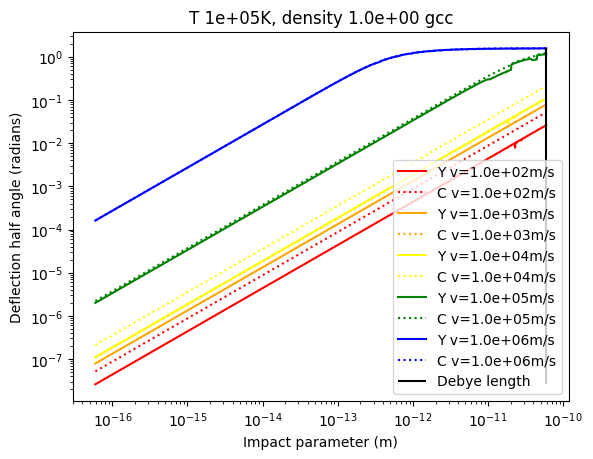

In [7]:

condi = 3
A,k0,lD = Ak0(conditions[condi,:])
rhoarr = np.logspace(np.log10(lD)-6,np.log10(lD),1000)
varr = np.array([1e2,1e3,1e4,1e5,1e6])
results = np.zeros((len(varr),len(rhoarr)))
resultsC = np.zeros((len(varr),len(rhoarr)))
colors=["red","orange","yellow","green","blue","purple"]
for i in range(len(varr)):
    for j in range(len(rhoarr)):
        E = 0.5*mu*varr[i]**2
        results[i,j] = phiY(rhoarr[j],E,A,k0,lD)
        resultsC[i,j] = phiC(rhoarr[j],E,A,k0,lD)
    plt.plot(rhoarr,results[i,:],label="Y v={:.1e}m/s".format(varr[i]),color=colors[i])
    plt.plot(rhoarr,resultsC[i,:],label="C v={:.1e}m/s".format(varr[i]),color=colors[i],ls=":")
print(results)
plt.xlabel("Impact parameter (m)")
plt.ylabel("Deflection half angle (radians)")
plt.yscale("log")
plt.xscale("log")
plt.vlines(lD,ymin = np.min(results),ymax=np.max(results),label="Debye length",color="black")
plt.title("T {:.1}K, density {:.1e} gcc".format(conditions[condi,3],conditions[condi,2]))
# plt.xscale("log")
plt.legend()


denom
[-0.00000000e+00 -2.71592399e-10 -1.08636959e-09 -2.44433159e-09
 -4.34547838e-09 -6.78980996e-09 -9.77732635e-09 -1.33080275e-08
 -1.73819135e-08 -2.19989843e-08 -2.71592399e-08 -3.28626802e-08
 -3.91093054e-08 -4.58991154e-08 -5.32321101e-08 -6.11082897e-08
 -6.95276540e-08 -7.84902032e-08 -8.79959371e-08 -9.80448559e-08
 -1.08636960e-07 -1.19772248e-07 -1.31450724e-07 -1.43672390e-07
 -1.56437260e-07 -1.69745372e-07 -1.83596819e-07 -1.97991819e-07
 -2.12930850e-07 -2.28414887e-07 -2.44445817e-07 -2.61027111e-07
 -2.78164876e-07 -2.95869421e-07 -3.14157519e-07 -3.33055560e-07
 -3.52603807e-07 -3.72862003e-07 -3.93916550e-07 -4.15889517e-07
 -4.38949674e-07 -4.63325772e-07 -4.89322234e-07 -5.17337376e-07
 -5.47884248e-07 -5.81614139e-07 -6.19342708e-07 -6.62078698e-07
 -7.11055086e-07 -7.67762521e-07 -8.33984836e-07 -9.11836367e-07
 -1.00380082e-06 -1.11277135e-06 -1.24209157e-06 -1.39559705e-06
 -1.57765710e-06 -1.79321637e-06 -2.04783597e-06 -2.34773376e-06
 -2.69982358e-06 -3

C:\Users\shaoq\AppData\Local\Temp\ipykernel_15032\3947562363.py:61: RuntimeWarning: invalid value encountered in log
  guess= uarr[np.nanargmin(np.log(umaxfunc(uarr,rho,vrel,A,k0)))]
C:\Users\shaoq\AppData\Local\Temp\ipykernel_15032\3947562363.py:77: RuntimeWarning: divide by zero encountered in divide
  print((-((rho*u)**2)-(u*A*np.exp(-k0/u))/E))
C:\Users\shaoq\AppData\Local\Temp\ipykernel_15032\3947562363.py:78: RuntimeWarning: divide by zero encountered in divide
  return rho/(np.sqrt(1-((rho*u)**2)-(u*A*np.exp(-k0/u))/E))
C:\Users\shaoq\AppData\Local\Temp\ipykernel_15032\3947562363.py:81: RuntimeWarning: invalid value encountered in sqrt
  return rho/(np.sqrt(1-(rho*u)**2-C*u/E))


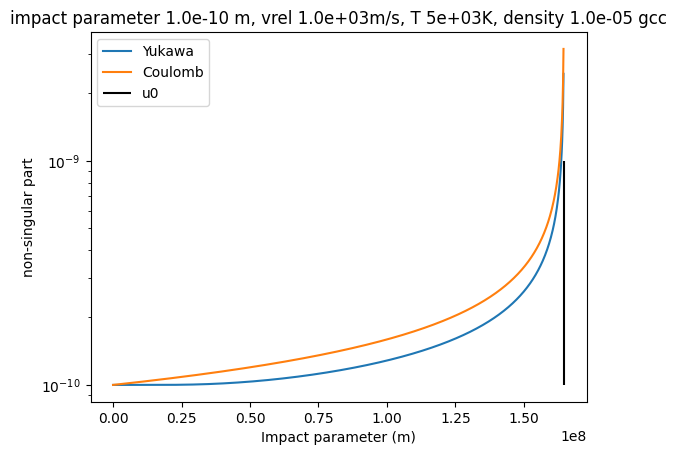

In [123]:

A,k0,lD = Ak0(conditions[0,:])
rho = 1e-10
vrel = 1e3
E = 0.5*mu*(vrel**2)
u0 = umax(rho,A,k0,lD,E)
C = A*math.exp(-k0/u0)
uarr = np.linspace(0,u0,1000)

plt.plot(uarr,Yint(uarr,rho,A,k0,E),label="Yukawa")
plt.plot(uarr,Cint(uarr,rho,E,C),label="Coulomb")

plt.xlabel("Impact parameter (m)")
plt.ylabel("non-singular part")
plt.yscale("log")
min = np.nanmin(Yint(uarr,rho,A,k0,E))
max = 10*min
plt.title("impact parameter {:.1e} m, vrel {:.1e}m/s, T {:.1}K, density {:.1e} gcc".format(rho,vrel,conditions[0,3],conditions[0,2]))
plt.vlines(u0,ymin=min,ymax=max,color="black",label="u0")
# plt.xscale("log")
plt.legend()


At distance of closest approach:
$$\frac{1}{2}m v^2 + U(r_{min}) = E$$
$$\frac{1}{2}m (\frac{L}{mr_{min}})^2 + U(r_{min}) = E$$
$$\frac{m^2b^2v_\infty^2}{2mr_{min}^2} + U(r_{min}) = \frac{1}{2}mv_\infty^2$$
$$f(r_{min}) = \frac{b^2}{r_{min}^2} + \frac{2U(r_{min})}{mv_\infty^2} -1 = 0$$



$$\frac{df}{dr} = -2\frac{b^2}{r^3} + \frac{2}{mv_\infty^2} (-A\frac{\exp(-k_0r)}{r^2}-Ak_0\frac{\exp(-k_0r)}{r})$$

$$F = n\iint f(v) d\sigma dv \; \Delta p$$
$$\Delta p = -p_0 (1+\cos(2\phi_0))$$
Use chain rule on 
$$d\sigma =\frac{\partial \sigma}{\partial \rho}d\rho = 2\pi\rho d\rho$$

$$F = -2\pi n\mu\iint f(v)\rho v (1+\cos (2\phi_0(\rho,v))) d\rho dv$$
Integrate 3D MB distribution over other 2 dimensions:
$$ \sqrt{\frac{m}{2\pi k_B T}}\exp(-\frac{mv^2}{2k_BT})$$

Convolution between hydrogen and silicon thermal speeds
$$\sigma_h^2 = k_BT/m_h$$
$$\sigma_s^2 = k_BT/m_s$$
$$\sigma_f^2 = k_BT/\mu$$


$$ \sqrt{\frac{\mu}{2\pi k_B T}}\exp(-\frac{\mu v^2}{2k_BT})$$

C:\Users\shaoq\AppData\Local\Temp\ipykernel_14564\3498012641.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  C = A*math.exp(-k0/u0)
C:\Users\shaoq\AppData\Local\Temp\ipykernel_14564\28857634.py:57: RuntimeWarning: divide by zero encountered in divide
  return (1-(A*u*np.exp(-k0/u)/(E))-((rho*u)**2))**2


-8.06276515196763


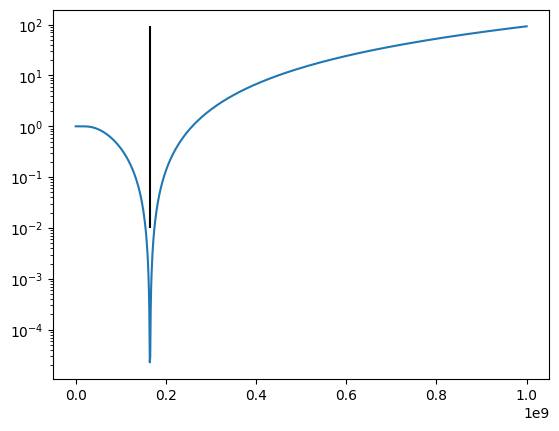

In [8]:
#plot umax
A,k0,lD = Ak0(conditions[0,:])
rho = 1e-10
vrel = 1e3
E = 0.5*mu*(vrel**2)
u0 = umax(rho,A,k0,lD,E)
C = A*math.exp(-k0/u0)
print(np.log10(lD))
uarr = np.linspace(0,1e9,1000,dtype=np.float64)
plt.plot(uarr,umaxfunc(uarr,rho,A,k0,E))
plt.vlines(u0,ymin=1e-2,ymax=np.nanmax(umaxfunc(uarr,rho,A,k0,E)),color="black")
plt.yscale("log")

In [ ]:
#plot rmin
A,k0,lD = Ak0(conditions[0,:])
rho = lD*1e-2
vrel = 1e6
rhoarr = np.logspace(np.log10(lD)-5,np.log10(lD),10000)
velarr = np.array([1e3,1e4,1e5,1e6])
result = np.zeros((len(velarr),len(rhoarr)))
for i in range(len(velarr)):
    for j in range(len(rhoarr)):
        # print(velarr[i],rhoarr[j])
        result[i,j] = rmin(rhoarr[j],velarr[i],A,k0,lD)
    plt.plot(rhoarr,result[i,:],label="{:.1e}m/s".format(velarr[i]))
plt.xlabel("Impact parameter (m)")
plt.ylabel(r"Closest approach $r_{min} (m)$")
plt.vlines(lD,ymin=np.min(result),ymax=np.max(result),color="black",label="Debye Length")
plt.hlines(lD, xmin = np.min(rhoarr),xmax = np.max(rhoarr),color="black")
plt.xscale("log")
plt.yscale("log")
print(np.min(result))
plt.legend()